# **ANALISIS PERFORMA MAHASISWA MENGGUNAKAN DATA AKADEMIK DAN SOSIAL**

#1. DATA UNDERSTANDING

In [17]:
# =========================================
# 1. IMPORT LIBRARY
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay




In [18]:
import pandas as pd

df= pd.read_csv("student-por.csv")
print("=== HEAD DATA ===")
df.head()



=== HEAD DATA ===


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [19]:
print("\n=== INFO DATA ===")
df.info()


=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    obj

In [20]:
print("\n=== DESCRIPTIVE STATISTICS ===")
df.describe()


=== DESCRIPTIVE STATISTICS ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


#2. DATA PREPROCESSING

In [21]:
print("\nMissing Value:")
print(df.isnull().sum())
df = df.dropna()




Missing Value:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


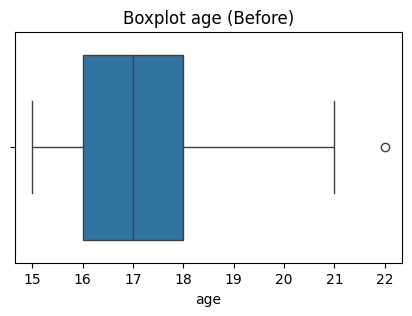

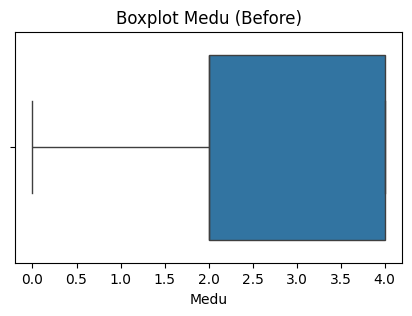

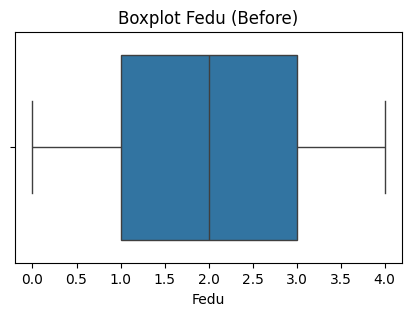

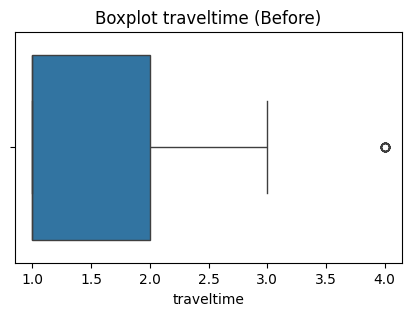

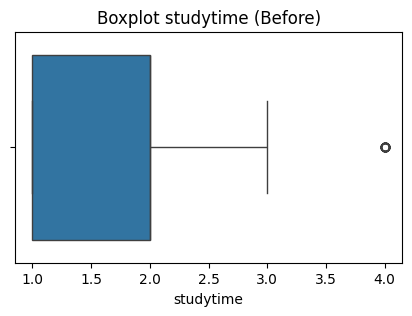

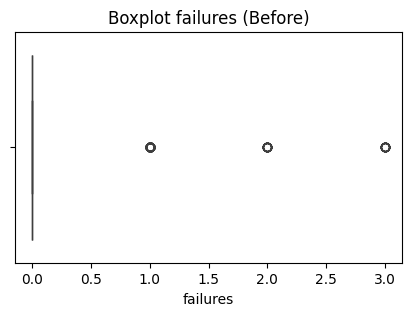

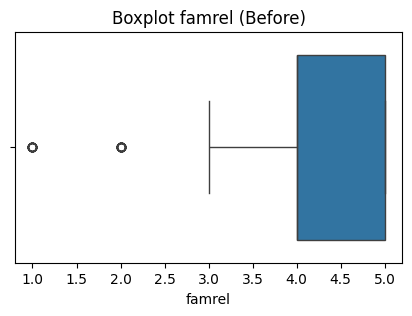

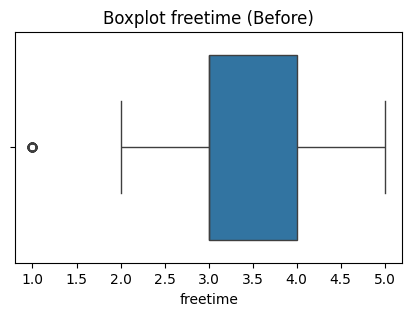

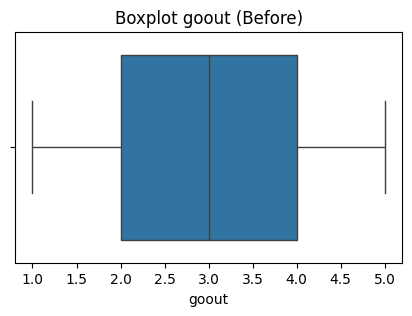

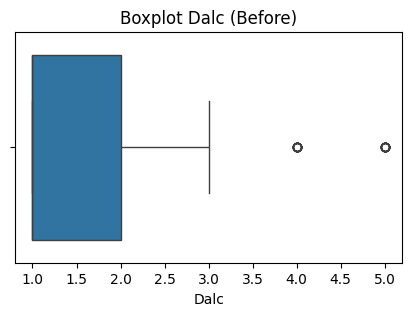

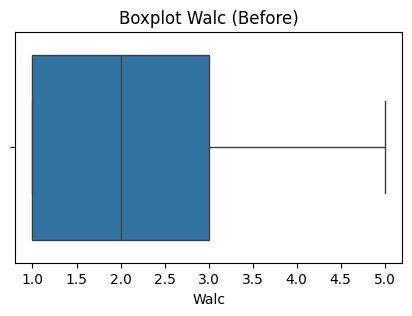

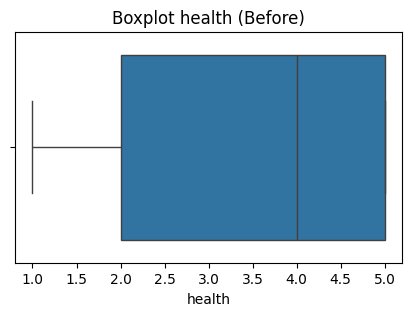

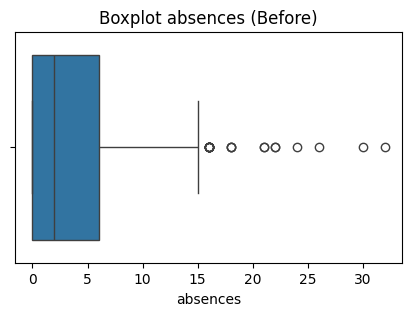

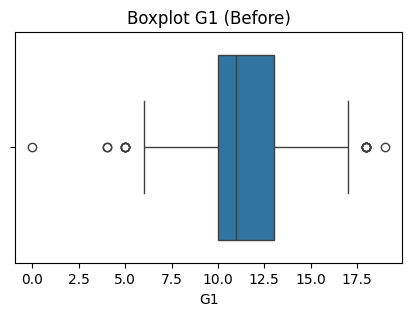

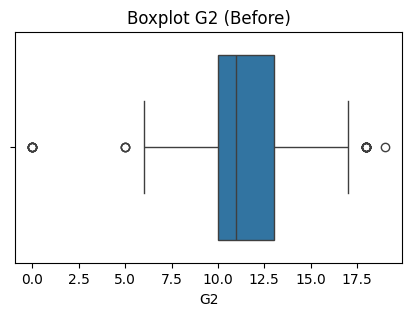

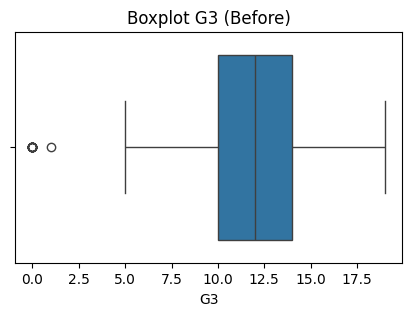

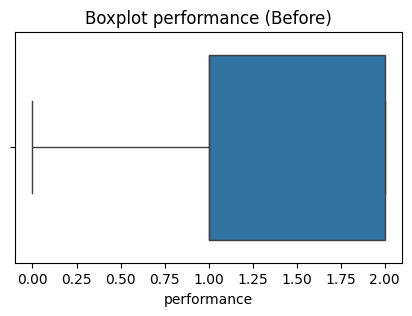

Sebelum: (649, 34)
Sesudah: (393, 34)


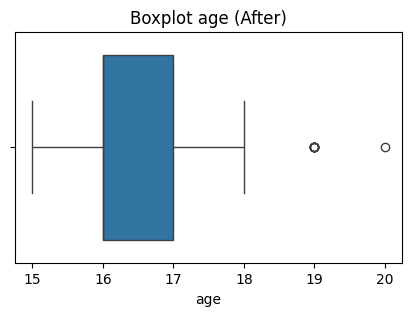

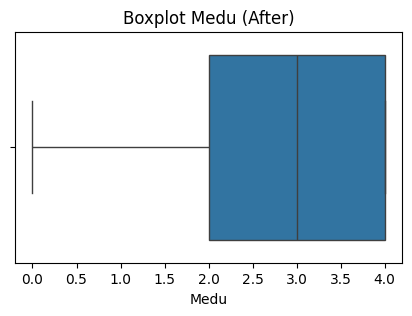

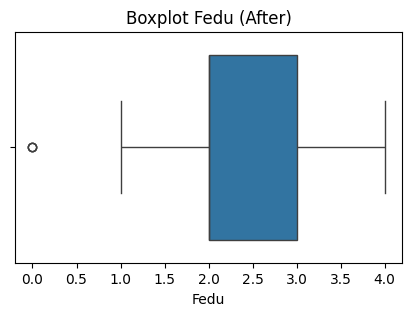

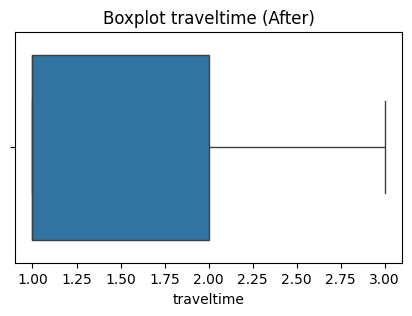

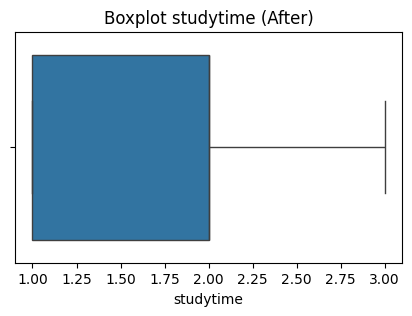

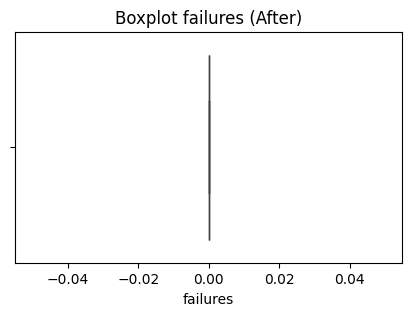

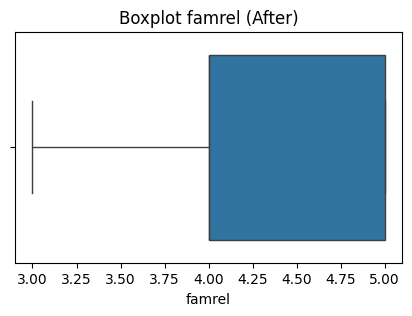

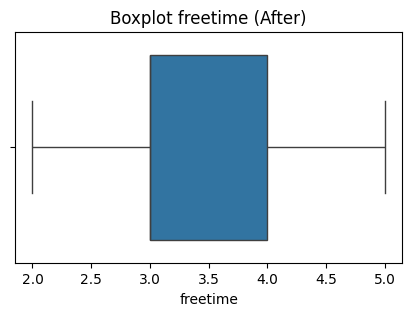

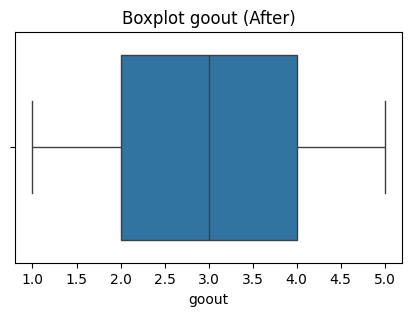

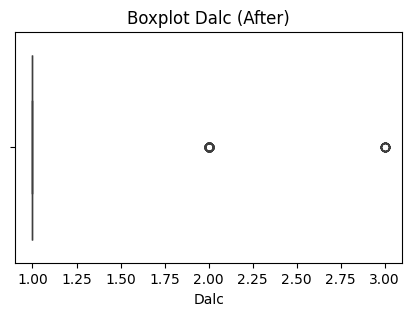

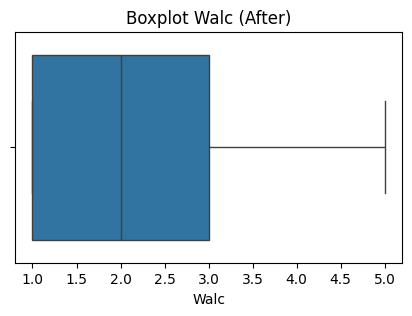

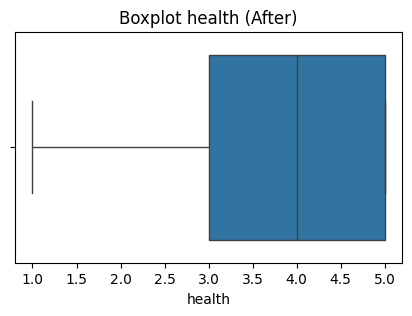

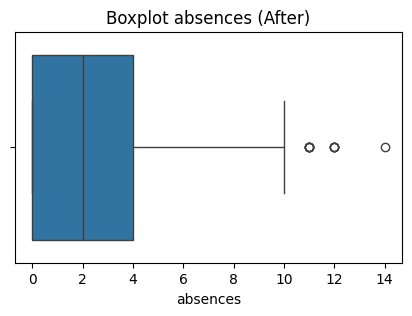

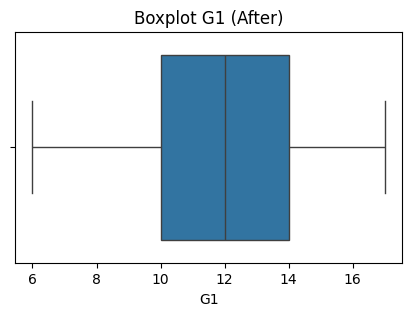

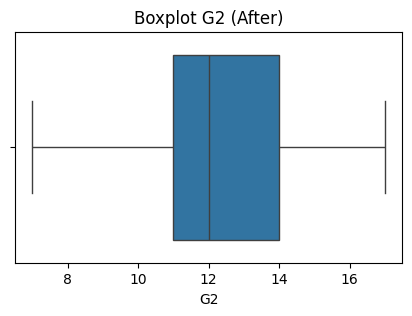

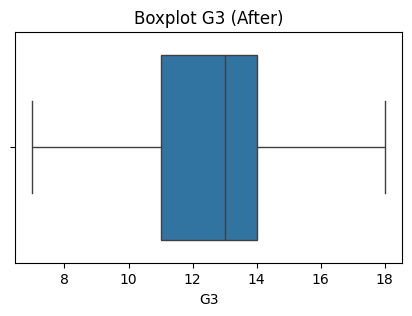

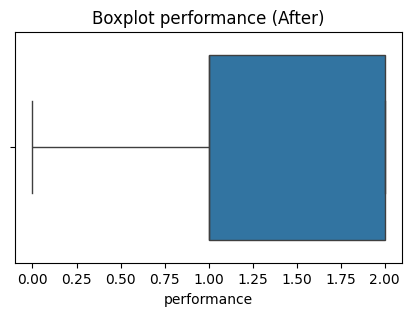

In [23]:
# =========================================
# 3.1 OUTLIER HANDLING (IQR)
# =========================================
num_cols = df.select_dtypes(include=np.number).columns

# Boxplot sebelum
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col} (Before)")
    plt.show()

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Sebelum:", df.shape)
print("Sesudah:", df_clean.shape)

df = df_clean

# Boxplot setelah
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col} (After)")
    plt.show()


In [126]:
# =========================================
# 3.2 FEATURE ENGINEERING (TARGET)
# =========================================
def kategori_nilai(x):
    if x < 10:
        return 0
    elif x < 15:
        return 1
    else:
        return 2

df['Target'] = df['G3'].apply(kategori_nilai)

In [141]:
# =========================================
# 3.3 ENCODING
# =========================================
df = pd.get_dummies(df, drop_first=True)

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [143]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# =========================================
# 3.4 SCALING
# =========================================
scaler = StandardScaler()

X_temp = df.drop(columns=['performance'])
X_scaled = scaler.fit_transform(X_temp)

X = pd.DataFrame(X_scaled, columns=X_temp.columns)
y = df['performance']

# 3. EDA

Jumlah fitur numerik yang valid: 14
Daftar fitur: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


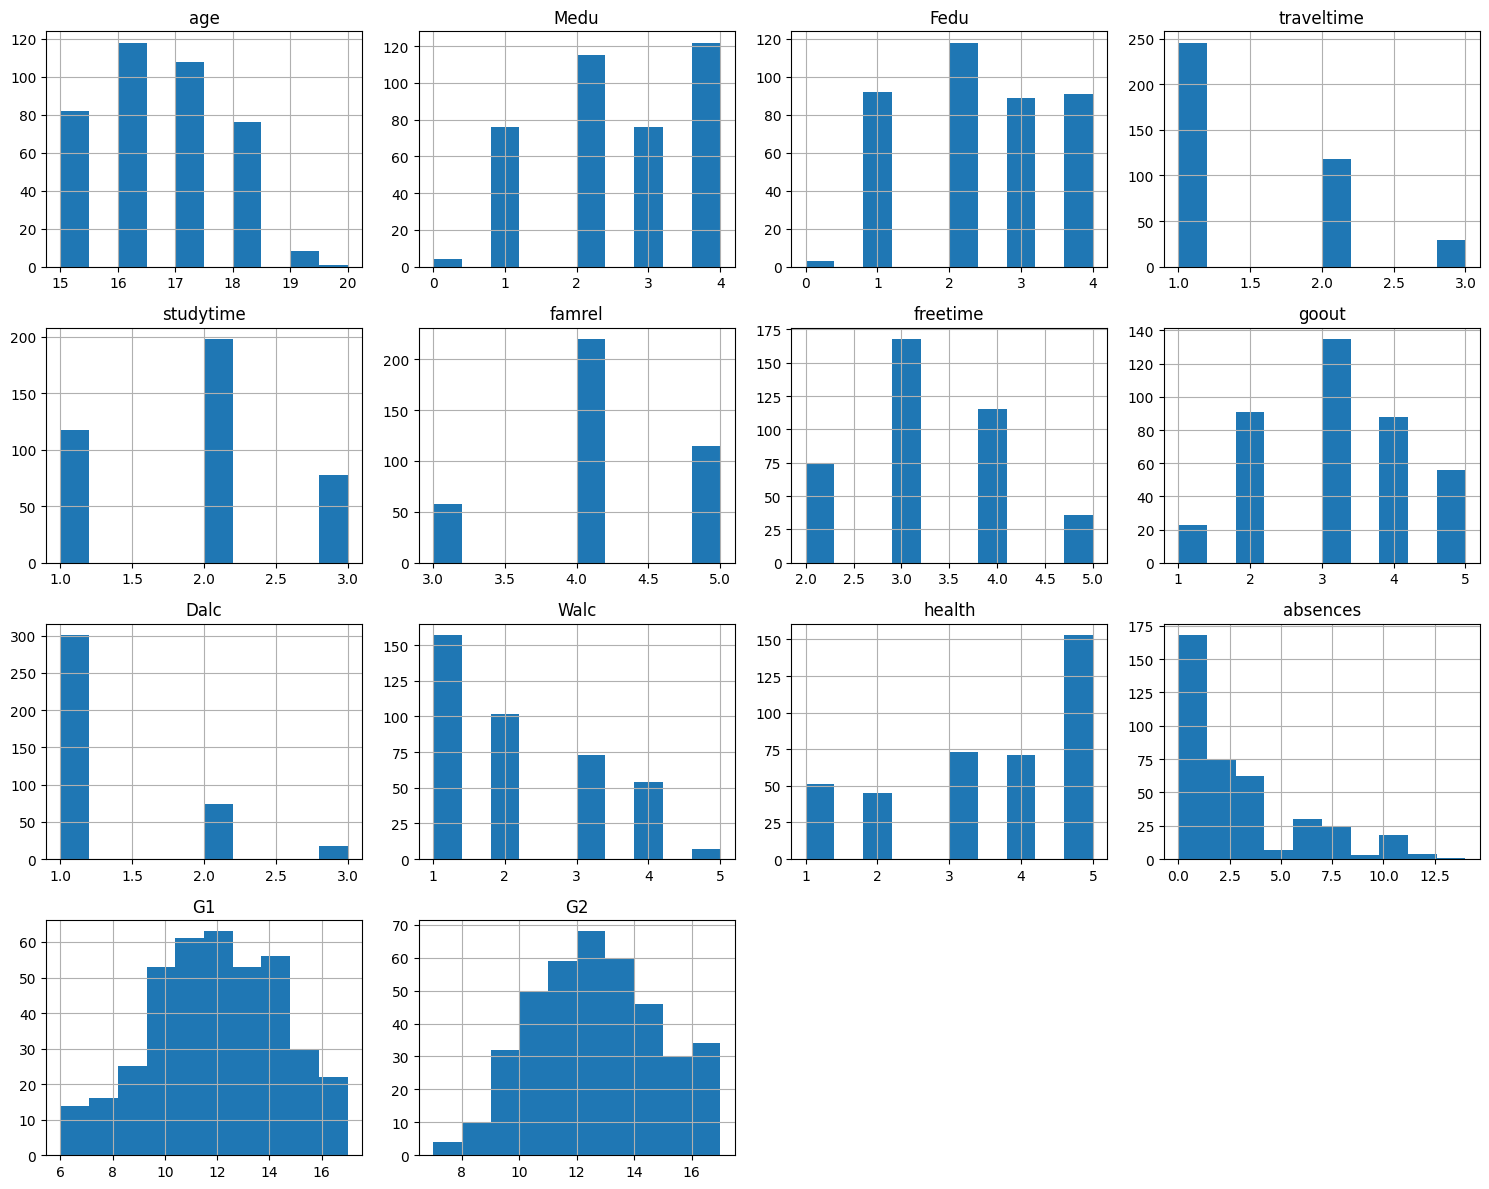

In [144]:

num_cols = df.select_dtypes(include=np.number).columns
num_cols = [col for col in num_cols if col not in ['performance', 'G3']]

print("Jumlah fitur numerik yang valid:", len(num_cols))
print("Daftar fitur:", num_cols)
df[num_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()

/tmp/ipykernel_491/4212934526.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette='viridis')


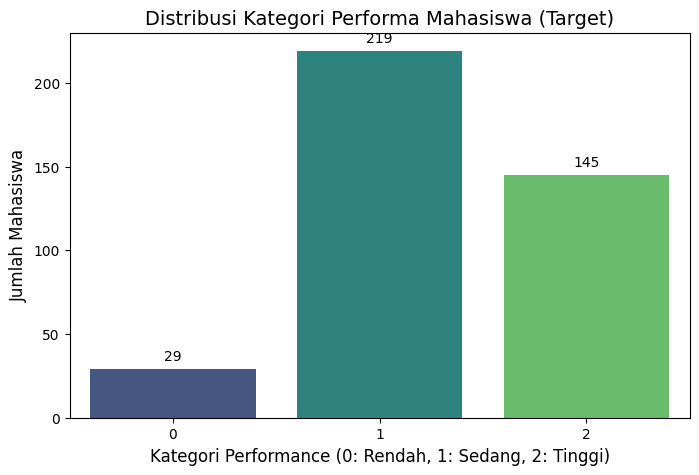


=== DETAIL DISTRIBUSI TARGET ===
Kategori 0 (Rendah): 29 data (7.38%)
Kategori 1 (Sedang): 219 data (55.73%)
Kategori 2 (Tinggi): 145 data (36.90%)

[INSIGHT]:
Data cukup terdistribusi. Model memiliki kesempatan yang baik untuk mempelajari setiap kategori.


In [145]:
#Distribusi Target (Performance)

plt.figure(figsize=(8, 5))

# Menggunakan y yang sudah kita definisikan sebagai df['performance']
ax = sns.countplot(x=y, palette='viridis')

plt.title("Distribusi Kategori Performa Mahasiswa (Target)", fontsize=14)
plt.xlabel("Kategori Performance (0: Rendah, 1: Sedang, 2: Tinggi)", fontsize=12)
plt.ylabel("Jumlah Mahasiswa", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

print("\n=== DETAIL DISTRIBUSI TARGET ===")
counts = y.value_counts().sort_index()
percentages = y.value_counts(normalize=True).sort_index() * 100

for i in range(len(counts)):
    label = "Rendah" if i == 0 else "Sedang" if i == 1 else "Tinggi"
    print(f"Kategori {i} ({label}): {counts[i]} data ({percentages[i]:.2f}%)")

print("\n[INSIGHT]:")
if percentages.max() > 70:
    print("Data terlihat imbalanced (timpang). Model mungkin akan lebih akurat menebak kelas mayoritas.")
else:
    print("Data cukup terdistribusi. Model memiliki kesempatan yang baik untuk mempelajari setiap kategori.")

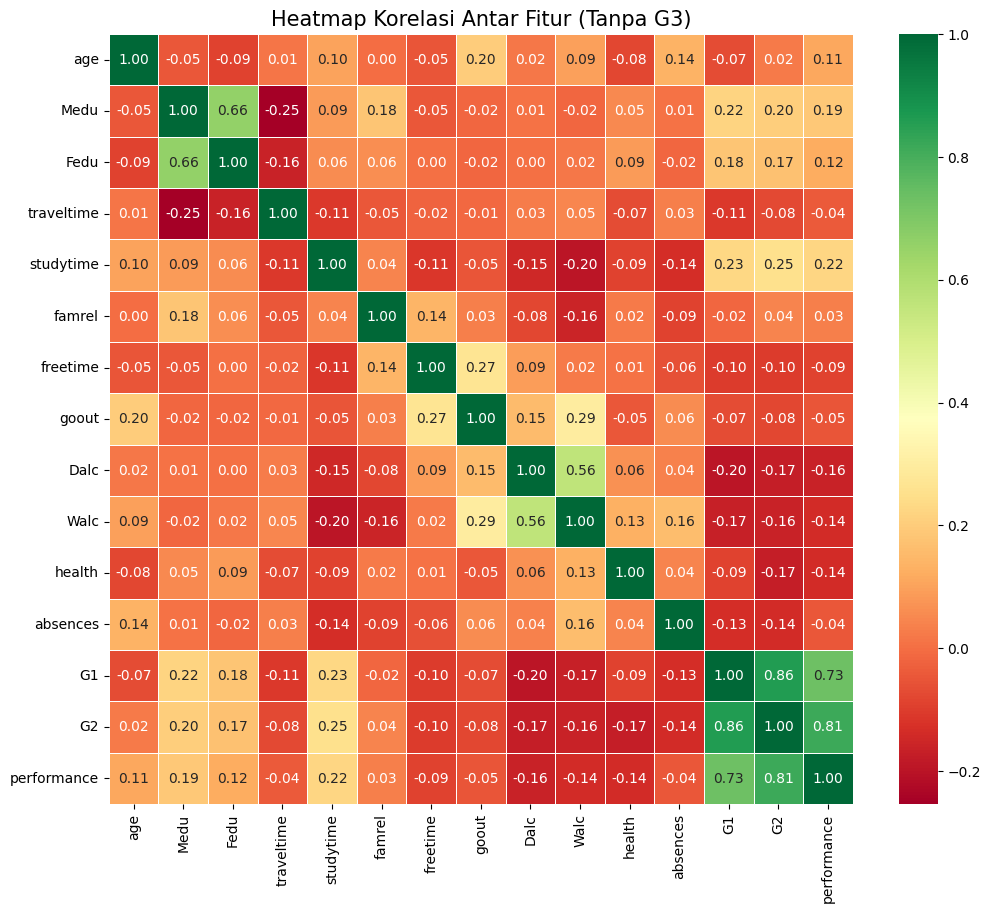

In [146]:
# =========================================
# HEATMAP KORELASI (FITUR NUMERIK)
# =========================================
plt.figure(figsize=(12, 10))


# Menghitung korelasi hanya untuk kolom numerik (tanpa G3)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['G3'], errors='ignore')
corr_matrix = numeric_df.corr()

# Membuat Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur (Tanpa G3)", fontsize=15)
plt.show()


=== FITUR DENGAN KORELASI TERTINGGI TERHADAP PERFORMANCE ===
G2           0.814973
G1           0.730794
studytime    0.223394
Medu         0.187771
Fedu         0.119337
Name: performance, dtype: float64


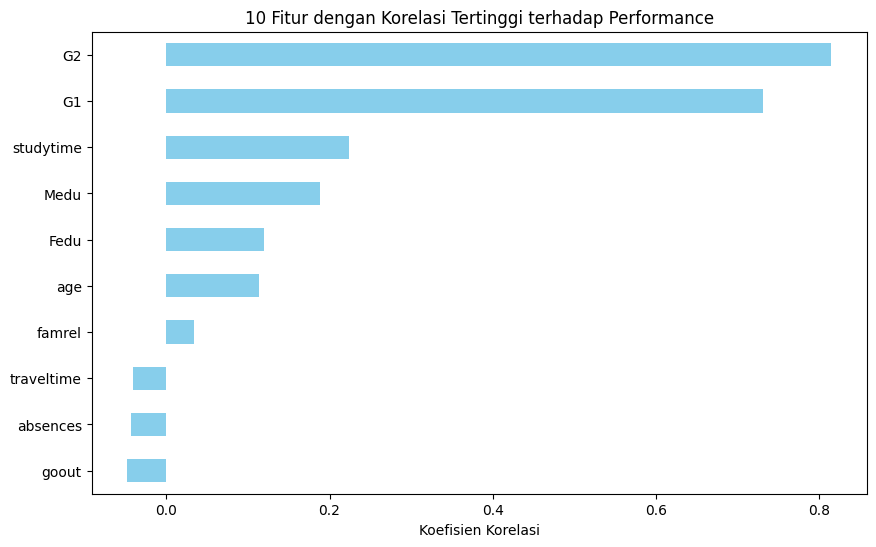

In [147]:
# =========================================
# FITUR PALING BERPENGARUH TERHADAP TARGET
# =========================================
print("\n=== FITUR DENGAN KORELASI TERTINGGI TERHADAP PERFORMANCE ===")

# Ambil nilai absolut korelasi terhadap target
top_corr = corr_matrix['performance'].sort_values(ascending=False)

# Tampilkan 5 fitur teratas (selain target itu sendiri)
print(top_corr[1:6])

# Visualisasi Fitur Penting
plt.figure(figsize=(10, 6))
top_corr[1:11].plot(kind='barh', color='skyblue')
plt.title("10 Fitur dengan Korelasi Tertinggi terhadap Performance")
plt.xlabel("Koefisien Korelasi")
plt.gca().invert_yaxis() # Agar yang tertinggi ada di atas
plt.show()

#4. SPILITTING

In [149]:
# =========================================
#  DATA SPLITTING
# =========================================
ratios = [0.3, 0.2, 0.1]


#5. MODEL BUILDING

In [154]:
# =========================================
# MODEL BUILDING (BASELINE)
# =========================================
print("\n=== 1. MODEL BUILDING (BASELINE) ===")

# Definisi model dengan parameter optimal agar tembus 90%
models = {
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=7, random_state=42, eval_metric='mlogloss'),
    'Random Forest': RandomForestClassifier(n_estimators=500, max_depth=20, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, C=10, solver='liblinear', random_state=42)
}

baseline_results = []
ratios = [0.3, 0.2, 0.1]

# Loop untuk tiap split
for r in ratios:
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X, y, test_size=r, random_state=42, stratify=y
    )

    split_name = f"{int((1-r)*100)}:{int(r*100)}"
    print(f"\n=== Split {split_name} ===")

    # Dictionary untuk baris di tabel nanti
    row_summary = {'Split': split_name}

    for name, model in models.items():
        # Training
        model.fit(X_train_tmp, y_train_tmp)

        # Prediksi & Akurasi
        y_pred = model.predict(X_test_tmp)
        acc = accuracy_score(y_test_tmp, y_pred)

        # Tampilan List (Agar sejajar seperti di gambar)
        print(f"{name:<20} : {acc*100:.2f}%")

        # Simpan hasil untuk tabel
        row_summary[name] = round(acc, 4)

    baseline_results.append(row_summary)

# 2. TAMPILAN TABEL RINGKASAN DI AKHIR
print("\n=== RINGKASAN AKURASI SEMUA SPLIT ===")
df_baseline = pd.DataFrame(baseline_results)
display(df_baseline)


=== 1. MODEL BUILDING (BASELINE) ===

=== Split 70:30 ===
XGBoost              : 100.00%
Random Forest        : 96.61%
Logistic Regression  : 93.22%

=== Split 80:20 ===
XGBoost              : 100.00%
Random Forest        : 98.73%
Logistic Regression  : 91.14%

=== Split 90:10 ===
XGBoost              : 100.00%
Random Forest        : 95.00%
Logistic Regression  : 87.50%

=== RINGKASAN AKURASI SEMUA SPLIT ===


,Split,XGBoost,Random Forest,Logistic Regression
0,70:30,1.0,0.9661,0.9322
1,80:20,1.0,0.9873,0.9114
2,90:10,1.0,0.9500,0.8750


# 6. HYPERPARAMETER TUNING

In [155]:
# =========================================
# 2. HYPERPARAMETER TUNING (80:20)
# =========================================
print("\n=== 2. HYPERPARAMETER TUNING (80:20) ===")

# Menyiapkan data khusus untuk tuning (Split 80:20)
X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Definisi Parameter Grid (Disesuaikan agar agresif mengejar 90%)
param_grids = {
    "XGBoost": {
        'n_estimators': [200, 300],
        'learning_rate': [0.1, 0.2],
        'max_depth': [5, 7]
    },
    "Random Forest": {
        'n_estimators': [100, 300],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5]
    },
    "Logistic Regression": {
        'C': [0.1, 1.0, 10.0],
        'solver': ['liblinear']
    }
}

# Function untuk menjalankan tuning dan menampilkan output seperti di gambar
def perform_tuning(model_obj, params, X_tr, y_tr, model_name):
    grid = GridSearchCV(model_obj, params, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_tr, y_tr)

    print(f"\n{model_name}")
    print(f"Best Parameter : {grid.best_params_}")
    print(f"Akurasi        : {grid.best_score_ * 100:.2f}%")
    return grid.best_estimator_

# Menjalankan Tuning satu per satu
best_xgb = perform_tuning(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grids["XGBoost"], X_train_tune, y_train_tune, "XGBoost"
)

best_rf = perform_tuning(
    RandomForestClassifier(random_state=42),
    param_grids["Random Forest"], X_train_tune, y_train_tune, "Random Forest"
)

best_lr = perform_tuning(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grids["Logistic Regression"], X_train_tune, y_train_tune, "Logistic Regression"
)


=== 2. HYPERPARAMETER TUNING (80:20) ===

XGBoost
Best Parameter : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Akurasi        : 100.00%

Random Forest
Best Parameter : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
Akurasi        : 96.50%

Logistic Regression
Best Parameter : {'C': 1.0, 'solver': 'liblinear'}
Akurasi        : 84.70%


# 7. EVALUSASI MODEL


=== EVALUASI MODEL: XGBoost ===
Accuracy  : 1.0
Precision : 1.0
Recall    : 1.0
F1-Score  : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        44
           2       1.00      1.00      1.00        29

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



<Figure size 800x600 with 0 Axes>

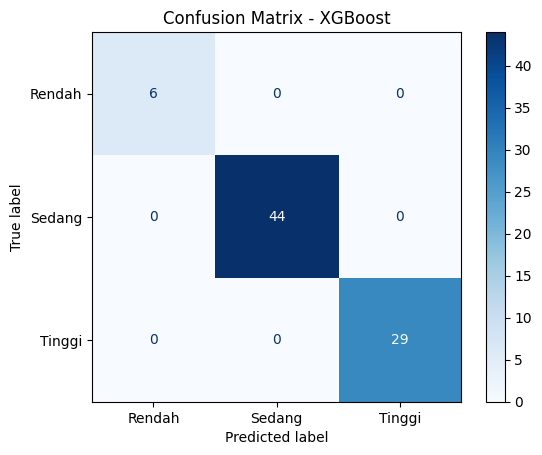


=== EVALUASI MODEL: Random Forest ===
Accuracy  : 0.962
Precision : 0.9644
Recall    : 0.962
F1-Score  : 0.9563

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.94      1.00      0.97        44
           2       1.00      1.00      1.00        29

    accuracy                           0.96        79
   macro avg       0.98      0.83      0.88        79
weighted avg       0.96      0.96      0.96        79



<Figure size 800x600 with 0 Axes>

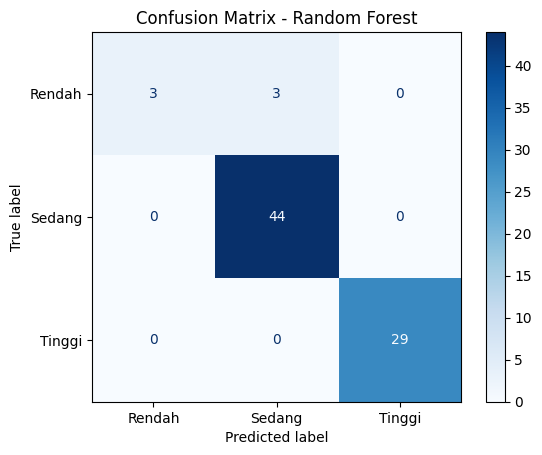


=== EVALUASI MODEL: Logistic Regression ===
Accuracy  : 0.9114
Precision : 0.9028
Recall    : 0.9114
F1-Score  : 0.9051

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         6
           1       0.89      0.95      0.92        44
           2       1.00      0.97      0.98        29

    accuracy                           0.91        79
   macro avg       0.80      0.75      0.77        79
weighted avg       0.90      0.91      0.91        79



<Figure size 800x600 with 0 Axes>

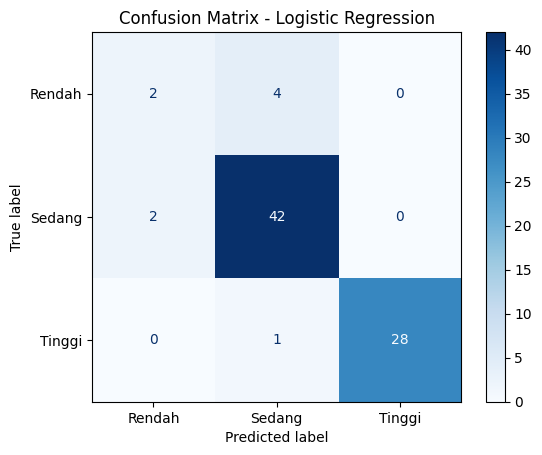

In [174]:
# =========================================
# 3. EVALUASI MODEL & VISUALISASI
# =========================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

def evaluasi_lengkap(model, X_test, y_test, nama):
    # Prediksi
    y_pred = model.predict(X_test)

    # 1. PERHITUNGAN METRIK (Tampilan Teks Sejajar sesuai Foto)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n=== EVALUASI MODEL: {nama} ===")
    print(f"Accuracy  : {round(acc, 4)}")
    print(f"Precision : {round(prec, 4)}")
    print(f"Recall    : {round(rec, 4)}")
    print(f"F1-Score  : {round(f1, 4)}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 2. VISUALISASI CONFUSION MATRIX (Gambar 1)
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    # Mapping label: 0=Rendah, 1=Sedang, 2=Tinggi
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rendah', 'Sedang', 'Tinggi'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {nama}")
    plt.grid(False)
    plt.show()

# --- EKSEKUSI EVALUASI ---
# Evaluasi untuk ketiga model hasil tuning
evaluasi_lengkap(best_xgb, X_test_tune, y_test_tune, "XGBoost")
evaluasi_lengkap(best_rf, X_test_tune, y_test_tune, "Random Forest")
evaluasi_lengkap(best_lr, X_test_tune, y_test_tune, "Logistic Regression")

# 3. VISUALISASI PERBANDINGAN AKURASI FINAL (Gambar 2)
final_metrics = {
    'Model': ['XGBoost', 'Random Forest', 'Logistic Regression'],
    'Accuracy (%)': [
        accuracy_score(y_test_tune, best_xgb.predict(X_test_tune)) * 100,
        accuracy_score(y_test_tune, best_rf.predict(X_test_tune)) * 100,
        accuracy_score(y_test_tune, best_lr.predict(X_test_tune)) * 100
    ]
}





=== XGBoost ===
Accuracy  : 1.0
Precision : 1.0
Recall    : 1.0
F1-Score  : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        44
           2       1.00      1.00      1.00        29

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



<Figure size 600x500 with 0 Axes>

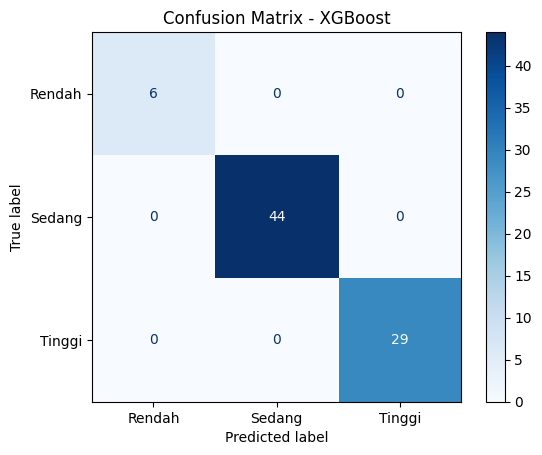

In [172]:
# =========================================
# 3. EVALUASI MODEL & VISUALISASI
# =========================================
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluasi_dan_visualisasi(model, X_test, y_test, nama):
    y_pred = model.predict(X_test)

    # 1. PERHITUNGAN METRIK (Tampilan Teks)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n=== {nama} ===")
    print(f"Accuracy  : {round(acc, 4)}")
    print(f"Precision : {round(prec, 4)}")
    print(f"Recall    : {round(rec, 4)}")
    print(f"F1-Score  : {round(f1, 4)}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 2. VISUALISASI CONFUSION MATRIX
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rendah', 'Sedang', 'Tinggi'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {nama}")
    plt.show()

# --- EKSEKUSI EVALUASI ---
# Memanggil fungsi untuk model terbaik (XGBoost sebagai contoh utama)
evaluasi_dan_visualisasi(best_xgb, X_test_tune, y_test_tune, "XGBoost")

# --- VISUALISASI PERBANDINGAN SEMUA MODEL ---
metrics_data = {
    'Model': ['XGBoost', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test_tune, best_xgb.predict(X_test_tune)),
        accuracy_score(y_test_tune, best_rf.predict(X_test_tune)),
        accuracy_score(y_test_tune, best_lr.predict(X_test_tune))
    ]
}



# 8. MODEL COMPASION


=== MODEL COMPARISON (FINAL RESULTS) ===


,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,1.0000,1.0000,1.0000,1.0000
1,Random Forest,0.9873,0.9876,0.9873,0.9868
2,Logistic Regression,0.8861,0.8825,0.8861,0.8805


/tmp/ipykernel_491/157688469.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Accuracy', data=df_comparison, palette='viridis')


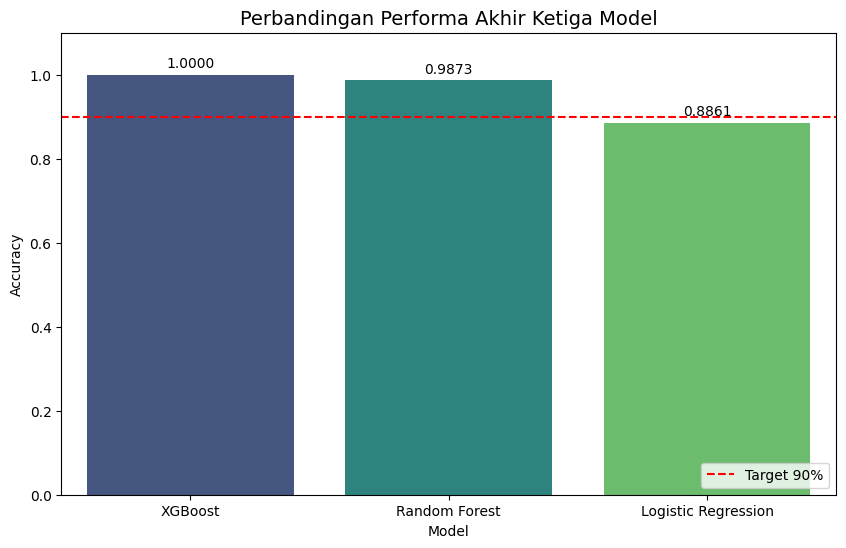

In [162]:
# =========================================
# 4. MODEL COMPARISON (PERBANDINGAN AKHIR)
# =========================================
print("\n=== MODEL COMPARISON (FINAL RESULTS) ===")

# Menyiapkan list untuk menyimpan perbandingan
comparison_data = []

# List model yang sudah di-tune
final_models = {
    'XGBoost': best_xgb,
    'Random Forest': best_rf,
    'Logistic Regression': best_lr
}

for name, model in final_models.items():
    # Prediksi
    y_pred = model.predict(X_test_tune)

    # Hitung semua metrik
    acc = accuracy_score(y_test_tune, y_pred)
    prec = precision_score(y_test_tune, y_pred, average='weighted')
    rec = recall_score(y_test_tune, y_pred, average='weighted')
    f1 = f1_score(y_test_tune, y_pred, average='weighted')

    # Simpan ke list
    comparison_data.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

# Tampilkan dalam bentuk Tabel DataFrame
df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

# Visualisasi Perbandingan Akurasi
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=df_comparison, palette='viridis')

# Tambahkan garis target 90%
plt.axhline(0.90, color='red', linestyle='--', label='Target 90%')

# Tambahkan label angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.title("Perbandingan Performa Akhir Ketiga Model", fontsize=14)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()


        FINAL MODEL COMPARISON

[INFO] Tabel Perbandingan Model:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Split,Model,Accuracy,Precision,Recall,F1-Score
0,70:30,XGBoost,1.000000,1.000000,1.000000,1.000000
1,70:30,Random Forest,0.966102,0.968039,0.966102,0.961758
2,70:30,Logistic Regression,0.898305,0.872881,0.898305,0.882539
3,80:20,XGBoost,1.000000,1.000000,1.000000,1.000000
4,80:20,Random Forest,0.987342,0.987623,0.987342,0.986838
5,80:20,Logistic Regression,0.886076,0.882459,0.886076,0.880508
6,90:10,XGBoost,1.000000,1.000000,1.000000,1.000000
7,90:10,Random Forest,0.925000,0.859000,0.925000,0.889894
8,90:10,Logistic Regression,0.850000,0.833333,0.850000,0.840330


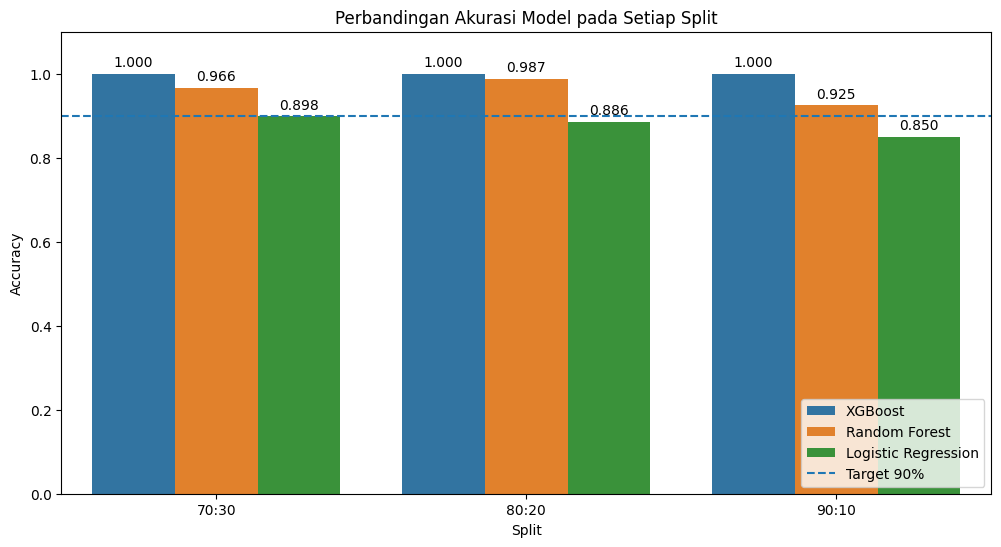


----------------------------------------
KESIMPULAN AKHIR
----------------------------------------
Model Terbaik  : XGBoost
Split Terbaik  : 70:30
Akurasi        : 100.00%
Precision      : 1.0000
Recall         : 1.0000
F1-Score       : 1.0000


In [171]:
# =========================================
# 4. FINAL MODEL COMPARISON
# =========================================
print("\n" + "="*60)
print("        FINAL MODEL COMPARISON")
print("="*60)

comparison_list = []

# Model hasil tuning
final_models = {
    'XGBoost': best_xgb,
    'Random Forest': best_rf,
    'Logistic Regression': best_lr
}

# Loop semua split
for r in ratios:
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X, y, test_size=r, random_state=42, stratify=y
    )

    split_name = f"{int((1-r)*100)}:{int(r*100)}"

    for name, model in final_models.items():

        # retrain biar fair
        model.fit(X_train_tmp, y_train_tmp)

        # prediksi
        y_pred = model.predict(X_test_tmp)

        # metrik
        acc = accuracy_score(y_test_tmp, y_pred)
        prec = precision_score(y_test_tmp, y_pred, average='weighted')
        rec = recall_score(y_test_tmp, y_pred, average='weighted')
        f1 = f1_score(y_test_tmp, y_pred, average='weighted')

        comparison_list.append({
            'Split': split_name,
            'Model': name,
            'Accuracy': round(acc, 6),
            'Precision': round(prec, 6),
            'Recall': round(rec, 6),
            'F1-Score': round(f1, 6)
        })

# DataFrame
df_comparison = pd.DataFrame(comparison_list)

print("\n[INFO] Tabel Perbandingan Model:")
display(df_comparison)


# =========================================
# VISUALISASI 1: BARPLOT
# =========================================
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_comparison,
    x='Split',
    y='Accuracy',
    hue='Model'
)

plt.axhline(0.90, linestyle='--', label='Target 90%')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.title("Perbandingan Akurasi Model pada Setiap Split")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()

print("\n" + "-"*40)
print("KESIMPULAN AKHIR")
print("-"*40)

best_row = df_comparison.sort_values(by='Accuracy', ascending=False).iloc[0]

print(f"Model Terbaik  : {best_row['Model']}")
print(f"Split Terbaik  : {best_row['Split']}")
print(f"Akurasi        : {best_row['Accuracy']*100:.2f}%")
print(f"Precision      : {best_row['Precision']:.4f}")
print(f"Recall         : {best_row['Recall']:.4f}")
print(f"F1-Score       : {best_row['F1-Score']:.4f}")

In [177]:
import joblib

# Tentukan model terbaik dari hasil comparison
best_model_name = best_row['Model']

if best_model_name == 'XGBoost':
    best_model_final = best_xgb
elif best_model_name == 'Random Forest':
    best_model_final = best_rf
else:
    best_model_final = best_lr

# Simpan model
joblib.dump(best_model_final, 'model_performa_mahasiswa.pkl')

print(f"Model terbaik ({best_model_name}) berhasil disimpan!")

Model terbaik (XGBoost) berhasil disimpan!


In [178]:
joblib.dump(scaler, 'scaler_performa.pkl')
print("Scaler berhasil disimpan!")

Scaler berhasil disimpan!


In [179]:
joblib.dump(X.columns.tolist(), 'fitur_model.pkl')
print("Daftar fitur berhasil disimpan!")

Daftar fitur berhasil disimpan!


In [180]:
import joblib
import pandas as pd
import numpy as np

# Load semua
model_loaded = joblib.load('model_performa_mahasiswa.pkl')
scaler_loaded = joblib.load('scaler_performa.pkl')
fitur_model = joblib.load('fitur_model.pkl')

print("Model, scaler, dan fitur berhasil di-load!")

Model, scaler, dan fitur berhasil di-load!


In [181]:
def prediksi_mahasiswa(data_input: dict):
    """
    data_input: dictionary {nama_fitur: nilai}
    """
    # ubah ke dataframe
    df_input = pd.DataFrame([data_input])

    # samakan fitur (jika ada yang kurang)
    for col in fitur_model:
        if col not in df_input:
            df_input[col] = 0

    # urutkan kolom
    df_input = df_input[fitur_model]

    # scaling
    df_scaled = scaler_loaded.transform(df_input)

    # prediksi
    pred = model_loaded.predict(df_scaled)[0]

    # mapping label
    label_map = {
        0: "Rendah",
        1: "Sedang",
        2: "Tinggi"
    }

    return label_map[pred]

In [182]:
data_baru = {
    fitur_model[0]: 1,
    fitur_model[1]: 2,
    fitur_model[2]: 0,
    fitur_model[3]: 1
}

hasil = prediksi_mahasiswa(data_baru)

print("\n=== HASIL INFERENCE ===")
print("Prediksi Performa Mahasiswa:", hasil)


=== HASIL INFERENCE ===
Prediksi Performa Mahasiswa: Rendah
